# Weather Rain Prediction

**Задача:** построить модель бинарной классификации, которая по погодным данным определяет, будет ли дождь на следующий день (`RainTomorrow`)

**Датасет:** Kaggle `jsphyg/weather-dataset-rattle-package`


## 1. Импорты и fixed seed

`RANDOM_STATE = 42` используется во всех экспериментах


In [1]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import ParameterGrid
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.config import LEAKAGE_COLUMNS, MODELS_DIR, RANDOM_STATE, TARGET
from src.data_loading import find_weather_csv, load_weather_data
from src.evaluate import (
    evaluate_binary_classifier,
    find_best_threshold,
    metrics_to_row,
    predict_proba_positive,
)
from src.features import ColumnDropper, FeatureEngineer
from src.preprocessing import (
    OutlierClipper,
    basic_clean,
    build_column_preprocessor,
    build_pipeline,
    chronological_train_val_test_split,
    split_features_target,
)
from src.utils import ensure_project_dirs, set_seed
from src.visualize import plot_missing_values, plot_target_balance

set_seed(RANDOM_STATE)
ensure_project_dirs()

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## 2. Самостоятельная загрузка и парсинг данных



```python
import kagglehub
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")
print("Path to dataset files:", path)
```


In [2]:
import kagglehub

path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")

print("Path to dataset files:", path)

csv_path = find_weather_csv(path)
print("CSV file:", csv_path)

df_raw = load_weather_data(csv_path)
df_raw.head()

Path to dataset files: /home/kali/.cache/kagglehub/datasets/jsphyg/weather-dataset-rattle-package/versions/2
CSV file: /home/kali/.cache/kagglehub/datasets/jsphyg/weather-dataset-rattle-package/versions/2/weatherAUS.csv


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 3. Первичный обзор данных

Проверяем:

- размер данных
- количество исходных признаков
- типы
- долю пропусков
- дубликаты
- баланс целевого класса


In [3]:
print("Raw shape:", df_raw.shape)
print("Raw feature count without target:", df_raw.drop(columns=[TARGET]).shape[1])
print("Duplicates:", df_raw.duplicated().sum())

overview = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(2),
    "n_unique": df_raw.nunique(dropna=True),
})
overview.sort_values("missing_percent", ascending=False).head(20)

Raw shape: (145460, 23)
Raw feature count without target: 22
Duplicates: 0


,dtype,missing_count,missing_percent,n_unique
Sunshine,float64,69835,48.01,145
Evaporation,float64,62790,43.17,358
Cloud3pm,float64,59358,40.81,10
Cloud9am,float64,55888,38.42,10
Pressure9am,float64,15065,10.36,546
Pressure3pm,float64,15028,10.33,549
WindDir9am,object,10566,7.26,16
WindGustDir,object,10326,7.10,16
WindGustSpeed,float64,10263,7.06,67
Humidity3pm,float64,4507,3.10,101


In [4]:
df_raw[TARGET].value_counts(dropna=False).to_frame("count")

,count
RainTomorrow,
No,110316
Yes,31877
NaN,3267


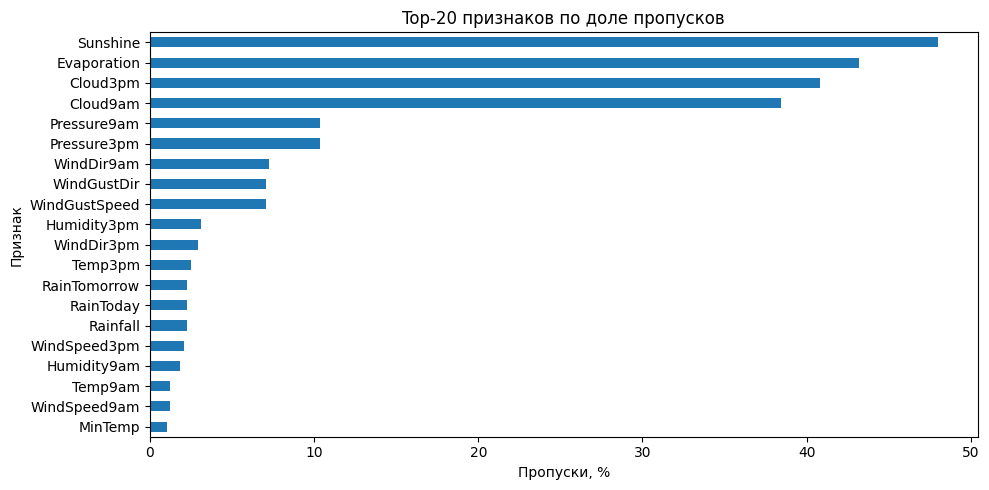

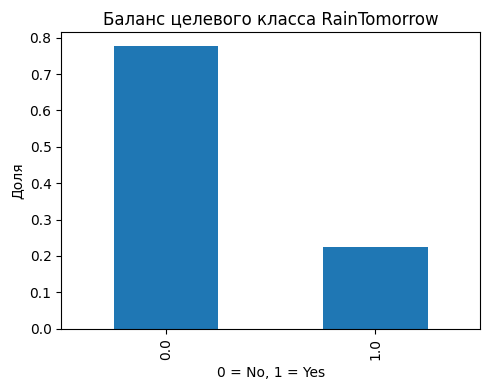

In [5]:
plot_missing_values(df_raw, top_n=20)
plt.show()

target_for_plot = df_raw[TARGET].map({"No": 0, "Yes": 1})
plot_target_balance(target_for_plot.dropna())
plt.show()

## 4. Очистка данных

1. удаляем дубликаты
2. приводим `Date` к `datetime`
3. удаляем строки без `RainTomorrow`
4. переводим `RainTomorrow`: `No -> 0`, `Yes -> 1`
5. `RISK_MM` считаем leakage-признаком и не используем в моделях
6. пропуски, OHE, scaling и clipping выполняются внутри `Pipeline`, чтобы fit происходил только на train


In [6]:
df = basic_clean(df_raw)

print("Shape after basic cleaning:", df.shape)
print("Duplicates after cleaning:", df.duplicated().sum())
print("Target values:", df[TARGET].value_counts(normalize=True).round(3).to_dict())

if "Date" in df.columns:
    print("Date range:", df["Date"].min(), "—", df["Date"].max())

print("Leakage columns to drop:", LEAKAGE_COLUMNS)
df.head()

Shape after basic cleaning: (142193, 23)
Duplicates after cleaning: 0
Target values: {0: 0.776, 1: 0.224}
Date range: 2007-11-01 00:00:00 — 2017-06-25 00:00:00
Leakage columns to drop: ['RISK_MM']


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0


## 5. Feature Engineering

Исходное количество признаков сравним с количеством признаков после добавления новых погодных и календарных фичей

Новые признаки:

- `Year`, `Month`, `DayOfYear`, `WeekOfYear`, `Season`
- `TempRange`, `TempMean`
- `HumidityChange`
- `PressureChange`
- `WindSpeedMean`
- `WindGustToMeanSpeed`
- `RainfallLog1p`
- `HadRainTodayByMm`
- `LowSunshine`


In [7]:
X_preview = df.drop(columns=[TARGET]).head(5)
engineered_preview = FeatureEngineer().fit_transform(X_preview)

original_feature_count = df.drop(columns=[TARGET]).shape[1]
engineered_feature_count = engineered_preview.shape[1]

new_features = sorted(set(engineered_preview.columns) - set(X_preview.columns))

print("Original feature count:", original_feature_count)
print("Feature count after feature engineering before OHE:", engineered_feature_count)
print("New features:", new_features)

engineered_preview.head()

Original feature count: 22
Feature count after feature engineering before OHE: 35
New features: ['DayOfYear', 'HadRainTodayByMm', 'HumidityChange', 'LowSunshine', 'Month', 'PressureChange', 'RainfallLog1p', 'Season', 'TempMean', 'TempRange', 'WeekOfYear', 'WindGustToMeanSpeed', 'WindSpeedMean', 'Year']


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Year,Month,DayOfYear,WeekOfYear,Season,TempRange,TempMean,HumidityChange,PressureChange,WindSpeedMean,WindGustToMeanSpeed,RainfallLog1p,HadRainTodayByMm,LowSunshine
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,2008,12,336,49.0,summer,9.5,18.15,-49.0,-0.6,22.0,2.000000,0.470004,1.0,0.0
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,2008,12,337,49.0,summer,17.7,16.25,-19.0,-2.8,13.0,3.384615,0.000000,0.0,0.0
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,2008,12,338,49.0,summer,12.8,19.30,-8.0,1.1,22.5,2.044444,0.000000,0.0,0.0
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,2008,12,339,49.0,summer,18.8,18.60,-29.0,-4.8,10.0,2.400000,0.000000,0.0,0.0
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,2008,12,340,49.0,summer,14.8,24.90,-49.0,-4.8,13.5,3.037037,0.693147,1.0,0.0


## 6. EDA и визуализации зависимостей

Смотрим связи признаков с целевой переменной


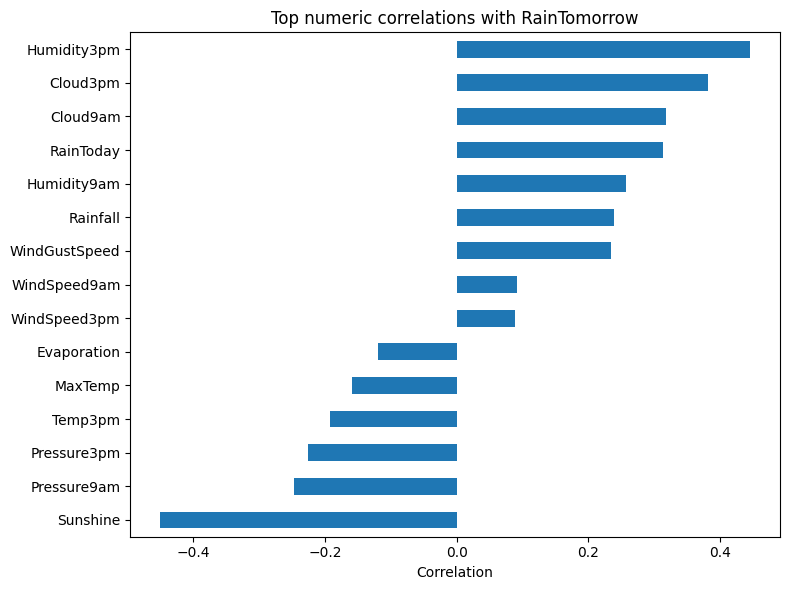

,corr_with_target
Sunshine,-0.450768
Humidity3pm,0.446160
Cloud3pm,0.381870
Cloud9am,0.317380
RainToday,0.313097
Humidity9am,0.257161
Pressure9am,-0.246371
Rainfall,0.239032
WindGustSpeed,0.234010
Pressure3pm,-0.226031


In [8]:
numeric_df = df.copy()
for col in ["RainToday", "RainTomorrow"]:
    if col in numeric_df.columns and numeric_df[col].dtype == "object":
        numeric_df[col] = numeric_df[col].map({"No": 0, "Yes": 1})

corr = (
    numeric_df.select_dtypes(include="number")
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
corr.sort_values().plot(kind="barh")
plt.title("Top numeric correlations with RainTomorrow")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

corr.to_frame("corr_with_target")


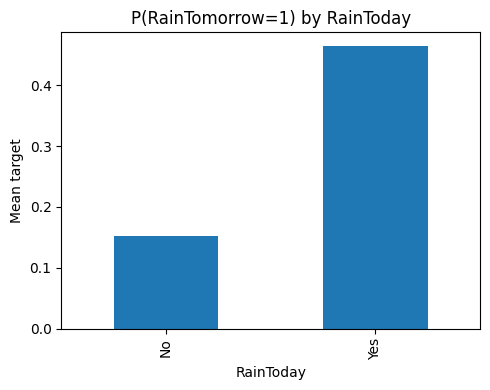

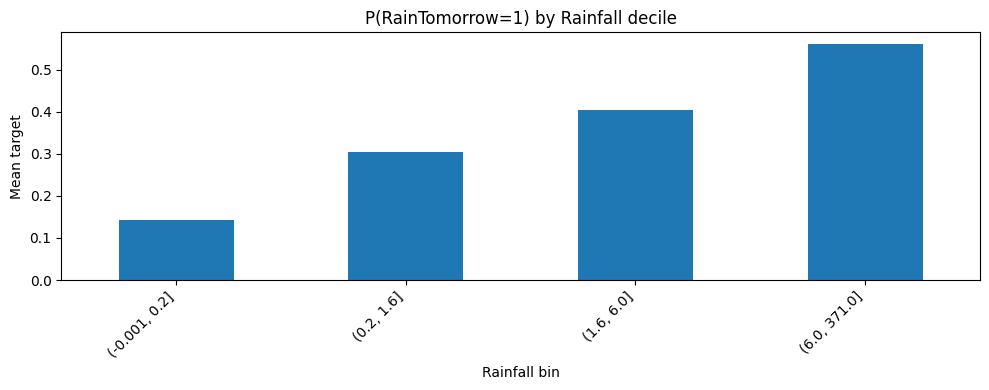

In [9]:
if "RainToday" in df.columns:
    rain_today_rate = df.groupby("RainToday")[TARGET].mean().sort_index()
    plt.figure(figsize=(5, 4))
    rain_today_rate.plot(kind="bar")
    plt.title("P(RainTomorrow=1) by RainToday")
    plt.xlabel("RainToday")
    plt.ylabel("Mean target")
    plt.tight_layout()
    plt.show()

if "Rainfall" in df.columns:
    tmp = df.copy()
    tmp["RainfallBin"] = pd.qcut(tmp["Rainfall"].fillna(0), q=10, duplicates="drop")
    rainfall_rate = tmp.groupby("RainfallBin", observed=False)[TARGET].mean()

    plt.figure(figsize=(10, 4))
    rainfall_rate.plot(kind="bar")
    plt.title("P(RainTomorrow=1) by Rainfall decile")
    plt.xlabel("Rainfall bin")
    plt.ylabel("Mean target")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

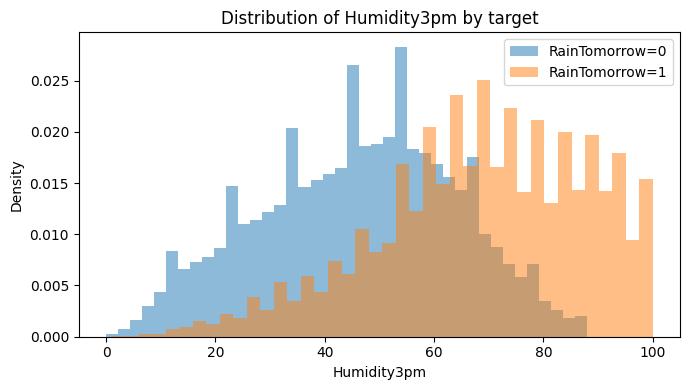

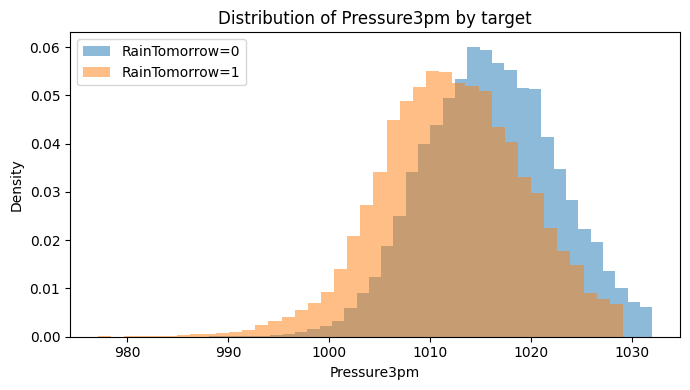

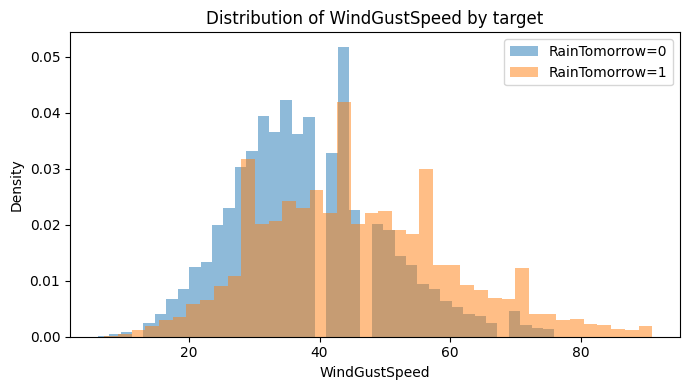

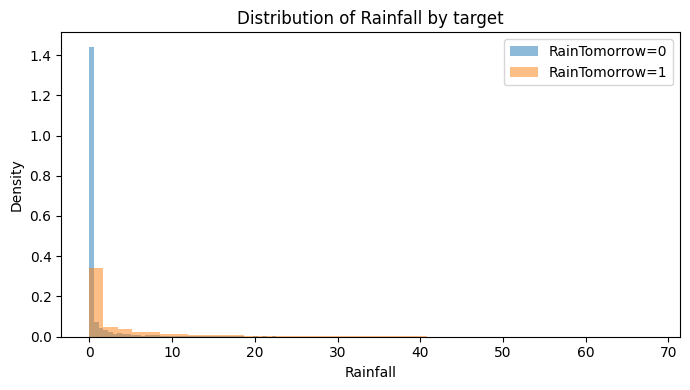

In [10]:
numeric_features_to_plot = [col for col in ["Humidity3pm", "Pressure3pm", "WindGustSpeed", "Rainfall", "TempRange"] if col in df.columns]

for col in numeric_features_to_plot:
    plt.figure(figsize=(7, 4))
    for target_value in [0, 1]:
        values = df.loc[df[TARGET] == target_value, col].dropna()
        # Ограничим хвост для читабельности
        upper = values.quantile(0.99) if len(values) else None
        values = values[values <= upper] if upper is not None else values
        plt.hist(values, bins=40, alpha=0.5, density=True, label=f"RainTomorrow={target_value}")
    plt.title(f"Distribution of {col} by target")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. Подготовка выборок

Используем хронологический split по `Date`:

- train: 70%
- validation: 15%
- test: 15%

Почему так:

- в реальном применении модель прогнозирует будущие дни
- random split может подмешать будущие наблюдения в train
- `RISK_MM` удаляется, потому что это количество дождя на следующий день и прямой leakage



In [11]:
train_df, val_df, test_df = chronological_train_val_test_split(df, train_size=0.70, val_size=0.15)

X_train, y_train = split_features_target(train_df)
X_val, y_val = split_features_target(val_df)
X_test, y_test = split_features_target(test_df)

split_info = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "target_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    "date_min": [train_df["Date"].min(), val_df["Date"].min(), test_df["Date"].min()],
    "date_max": [train_df["Date"].max(), val_df["Date"].max(), test_df["Date"].max()],
})
split_info

,split,rows,target_rate,date_min,date_max
0,train,99535,0.225639,2007-11-01,2015-01-12
1,val,21329,0.203995,2015-01-12,2016-04-08
2,test,21329,0.237564,2016-04-08,2017-06-25


## 8. Метрики качества

Основная метрика выбора модели: **PR-AUC**.

Обоснование:

- задача несбалансированная: дождь завтра встречается реже, чем отсутствие дождя
- accuracy может быть высокой даже у модели, которая плохо ловит дождливые дни
- PR-AUC лучше показывает качество на положительном классе `RainTomorrow = 1`

Дополнительно считаем:

- ROC-AUC
- F1
- Precision
- Recall
- Accuracy
- Confusion Matrix

Threshold подбираем только на validation по максимуму F1. Test используется только для финальной проверки

## 9. Baseline

Baseline - простая `LogisticRegression` без feature engineering
Она использует только базовую очистку, imputing, scaling и OneHotEncoding


In [12]:
baseline_model = LogisticRegression(
    max_iter=700,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

baseline_pipeline = build_pipeline(baseline_model, use_feature_engineering=False)
baseline_pipeline.fit(X_train, y_train)

baseline_val_score = predict_proba_positive(baseline_pipeline, X_val)
baseline_threshold, baseline_best_f1 = find_best_threshold(y_val, baseline_val_score)

baseline_val_metrics = evaluate_binary_classifier(
    baseline_pipeline, X_val, y_val, threshold=baseline_threshold
)
baseline_test_metrics = evaluate_binary_classifier(
    baseline_pipeline, X_test, y_test, threshold=baseline_threshold
)

pd.DataFrame([
    metrics_to_row("Baseline LogisticRegression", "val", baseline_val_metrics, baseline_threshold),
    metrics_to_row("Baseline LogisticRegression", "test", baseline_test_metrics, baseline_threshold),
])

,model,split,threshold,accuracy,precision,recall,f1,pr_auc,roc_auc
0,Baseline LogisticRegression,val,0.58,0.834591,0.585250,0.649276,0.615603,0.673437,0.867547
1,Baseline LogisticRegression,test,0.58,0.815463,0.597652,0.683047,0.637502,0.693955,0.857517


## 10. Основные модели

- Logistic Regression + feature engineering
- KNN
- RandomForest
- ExtraTrees
- GradientBoosting
- XGBoost, если установлен (для докера)
- LightGBM, если установлен (для докера)

In [13]:
FAST_MODE = False

n_estimators = 80 if FAST_MODE else 250

candidate_models = {
    "LogisticRegression + FE": LogisticRegression(
        max_iter=700,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "KNN + FE": KNeighborsClassifier(n_neighbors=15 if FAST_MODE else 35),
    "RandomForest + FE": RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=18,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "ExtraTrees + FE": ExtraTreesClassifier(
        n_estimators=n_estimators,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "GradientBoosting + FE": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

try:
    from xgboost import XGBClassifier

    if not FAST_MODE:
        candidate_models["XGBoost + FE"] = XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
except Exception as exc:
    print("XGBoost skipped:", exc)

try:
    from lightgbm import LGBMClassifier

    if not FAST_MODE:
        candidate_models["LightGBM + FE"] = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
except Exception as exc:
    print("LightGBM skipped:", exc)

candidate_models

{'LogisticRegression + FE': LogisticRegression(class_weight='balanced', max_iter=700, n_jobs=-1,
                    random_state=42),
 'KNN + FE': KNeighborsClassifier(n_neighbors=35),
 'RandomForest + FE': RandomForestClassifier(class_weight='balanced_subsample', max_depth=18,
                        min_samples_leaf=3, n_estimators=250, n_jobs=-1,
                        random_state=42),
 'ExtraTrees + FE': ExtraTreesClassifier(class_weight='balanced', min_samples_leaf=2,
                      n_estimators=250, n_jobs=-1, random_state=42),
 'GradientBoosting + FE': GradientBoostingClassifier(random_state=42),
 'XGBoost + FE': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.9, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=N

In [15]:
experiment_rows = [
    metrics_to_row("Baseline LogisticRegression", "val", baseline_val_metrics, baseline_threshold),
    metrics_to_row("Baseline LogisticRegression", "test", baseline_test_metrics, baseline_threshold),
]
fitted_models = {
    "Baseline LogisticRegression": baseline_pipeline,
}

for model_name, model in candidate_models.items():
    print(f"Training: {model_name}")
    pipeline = build_pipeline(model, use_feature_engineering=True)
    pipeline.fit(X_train, y_train)

    val_score = predict_proba_positive(pipeline, X_val)
    threshold, _ = find_best_threshold(y_val, val_score)

    val_metrics = evaluate_binary_classifier(pipeline, X_val, y_val, threshold)
    test_metrics = evaluate_binary_classifier(pipeline, X_test, y_test, threshold)

    experiment_rows.append(metrics_to_row(model_name, "val", val_metrics, threshold))
    experiment_rows.append(metrics_to_row(model_name, "test", test_metrics, threshold))
    fitted_models[model_name] = pipeline

results_df = pd.DataFrame(experiment_rows).sort_values(["split", "pr_auc"], ascending=[True, False])
results_df

Training: LogisticRegression + FE
Training: KNN + FE


Exception ignored in: <function ResourceTracker.__del__ at 0x7f075346a3e0>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f56c638a3e0>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7fcfb326a3e0>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/reso

Training: RandomForest + FE
Training: ExtraTrees + FE
Training: GradientBoosting + FE
Training: XGBoost + FE
Training: LightGBM + FE


,model,split,threshold,accuracy,precision,recall,f1,pr_auc,roc_auc
15,LightGBM + FE,test,0.33,0.835529,0.641805,0.696270,0.667929,0.740999,0.880035
13,XGBoost + FE,test,0.30,0.823574,0.610434,0.711269,0.657005,0.726754,0.871910
9,ExtraTrees + FE,test,0.39,0.815369,0.589052,0.736925,0.654743,0.719727,0.872427
7,RandomForest + FE,test,0.46,0.824746,0.615465,0.699033,0.654592,0.716132,0.870854
11,GradientBoosting + FE,test,0.27,0.815556,0.594971,0.700414,0.643401,0.709638,0.861822
3,LogisticRegression + FE,test,0.58,0.814712,0.593839,0.696270,0.640988,0.694923,0.860116
1,Baseline LogisticRegression,test,0.58,0.815463,0.597652,0.683047,0.637502,0.693955,0.857517
5,KNN + FE,test,0.26,0.800928,0.565817,0.696467,0.624381,0.648082,0.845763
14,LightGBM + FE,val,0.33,0.854095,0.641406,0.645829,0.643610,0.712421,0.886261
12,XGBoost + FE,val,0.30,0.845375,0.611429,0.663985,0.636624,0.704638,0.881682


## 11. Подбор гиперпараметров

Делаем небольшой перебор параметров для лучшей модели

In [18]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgbm_grid = {
    "n_estimators": [200] if FAST_MODE else [300, 500],
    "learning_rate": [0.05] if FAST_MODE else [0.03, 0.05],
    "num_leaves": [31] if FAST_MODE else [31, 63],
    "max_depth": [-1, 10] if FAST_MODE else [-1, 8, 12],
    "min_child_samples": [30] if FAST_MODE else [20, 40],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "reg_lambda": [1.0],
}

best_lgbm = None
best_lgbm_params = None
best_lgbm_pr_auc = -1

grid_rows = []

for params in ParameterGrid(lgbm_grid):
    print("LightGBM params:", params)

    lgbm = LGBMClassifier(
        **params,
        objective="binary",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1,
    )

    pipe = build_pipeline(lgbm, use_feature_engineering=True)
    pipe.fit(X_train, y_train)

    val_metrics = evaluate_binary_classifier(pipe, X_val, y_val)

    grid_rows.append({
        **params,
        **{k: v for k, v in val_metrics.items() if k != "confusion_matrix"},
    })

    if val_metrics["pr_auc"] > best_lgbm_pr_auc:
        best_lgbm_pr_auc = val_metrics["pr_auc"]
        best_lgbm_params = params
        best_lgbm = pipe

grid_results = pd.DataFrame(grid_rows).sort_values("pr_auc", ascending=False)
grid_results

LightGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31, 'reg_lambda': 1.0, 'subsample': 0.8}
LightGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 63, 'reg_lambda': 1.0, 'subsample': 0.8}
LightGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 500, 'num_leaves': 31, 'reg_lambda': 1.0, 'subsample': 0.8}
LightGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 500, 'num_leaves': 63, 'reg_lambda': 1.0, 'subsample': 0.8}
LightGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 40, 'n_estimators': 300, 'num_leaves': 31, 'reg_lambda': 1.0, 'subsample': 0.8}
LightGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -

,colsample_bytree,learning_rate,max_depth,min_child_samples,n_estimators,num_leaves,reg_lambda,subsample,accuracy,precision,recall,f1,pr_auc,roc_auc
39,0.8,0.05,8,40,500,63,1.0,0.8,0.836983,0.581016,0.720294,0.643202,0.722990,0.891111
47,0.8,0.05,12,40,500,63,1.0,0.8,0.838389,0.583241,0.727879,0.647582,0.722167,0.890825
31,0.8,0.05,-1,40,500,63,1.0,0.8,0.837733,0.581741,0.727879,0.646656,0.721950,0.890428
27,0.8,0.05,-1,20,500,63,1.0,0.8,0.837498,0.581267,0.727419,0.646182,0.721563,0.890065
43,0.8,0.05,12,20,500,63,1.0,0.8,0.838530,0.583594,0.727649,0.647709,0.721099,0.890163
37,0.8,0.05,8,40,300,63,1.0,0.8,0.831356,0.567106,0.732245,0.639181,0.720435,0.890193
30,0.8,0.05,-1,40,500,31,1.0,0.8,0.831591,0.566497,0.743048,0.642871,0.720222,0.889935
35,0.8,0.05,8,20,500,63,1.0,0.8,0.837358,0.581940,0.719835,0.643584,0.719948,0.889816
23,0.8,0.03,12,40,500,63,1.0,0.8,0.830794,0.565363,0.737532,0.640072,0.719713,0.890054
15,0.8,0.03,8,40,500,63,1.0,0.8,0.832153,0.568753,0.732935,0.640490,0.719656,0.889842


In [19]:
best_lgbm_score = predict_proba_positive(best_lgbm, X_val)
best_lgbm_threshold, i = find_best_threshold(y_val, best_lgbm_score)

best_lgbm_val_metrics = evaluate_binary_classifier(
    best_lgbm,
    X_val,
    y_val,
    best_lgbm_threshold,
)

best_lgbm_test_metrics = evaluate_binary_classifier(
    best_lgbm,
    X_test,
    y_test,
    best_lgbm_threshold,
)

tuned_lgbm_name = f"Tuned LightGBM + FE {best_lgbm_params}"

extra_rows = pd.DataFrame([
    metrics_to_row(
        tuned_lgbm_name,
        "val",
        best_lgbm_val_metrics,
        best_lgbm_threshold,
    ),
    metrics_to_row(
        tuned_lgbm_name,
        "test",
        best_lgbm_test_metrics,
        best_lgbm_threshold,
    ),
])

results_df = pd.concat([results_df, extra_rows], ignore_index=True)
fitted_models[tuned_lgbm_name] = best_lgbm

results_df.sort_values(["split", "pr_auc"], ascending=[True, False])

,model,split,threshold,accuracy,precision,recall,f1,pr_auc,roc_auc
17,"Tuned LightGBM + FE {'colsample_bytree': 0.8, ...",test,0.52,0.819401,0.592961,0.764752,0.667988,0.748909,0.884757
0,LightGBM + FE,test,0.33,0.835529,0.641805,0.696270,0.667929,0.740999,0.880035
1,XGBoost + FE,test,0.30,0.823574,0.610434,0.711269,0.657005,0.726754,0.871910
2,ExtraTrees + FE,test,0.39,0.815369,0.589052,0.736925,0.654743,0.719727,0.872427
3,RandomForest + FE,test,0.46,0.824746,0.615465,0.699033,0.654592,0.716132,0.870854
4,GradientBoosting + FE,test,0.27,0.815556,0.594971,0.700414,0.643401,0.709638,0.861822
5,LogisticRegression + FE,test,0.58,0.814712,0.593839,0.696270,0.640988,0.694923,0.860116
6,Baseline LogisticRegression,test,0.58,0.815463,0.597652,0.683047,0.637502,0.693955,0.857517
7,KNN + FE,test,0.26,0.800928,0.565817,0.696467,0.624381,0.648082,0.845763
16,"Tuned LightGBM + FE {'colsample_bytree': 0.8, ...",val,0.52,0.843687,0.598261,0.711561,0.650010,0.722990,0.891111


## 12. Ансамбли

Проверяем два ансамбля:

1. `SoftVoting`: усреднение вероятностей нескольких сильных моделей
2. `Stacking`: мета-модель поверх базовых моделей

Ансамбли обучаются только на train. Validation используется для выбора threshold и сравнения


In [22]:
try:
    lgbm_params_for_ensemble = best_lgbm_params.copy()
except NameError:
    lgbm_params_for_ensemble = {
        "n_estimators": 120,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 30,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
    }

lgbm_params_for_ensemble["n_estimators"] = min(
    lgbm_params_for_ensemble.get("n_estimators", 120),
    120,
)

ensemble_estimators = [
    (
        "lr",
        build_pipeline(
            LogisticRegression(
                max_iter=400,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            use_feature_engineering=True,
        ),
    ),
    (
        "lgbm",
        build_pipeline(
            LGBMClassifier(
                **lgbm_params_for_ensemble,
                objective="binary",
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=1,
                verbose=-1,
            ),
            use_feature_engineering=True,
        ),
    ),
]

print("Fitting fast SoftVoting ensemble...")

voting_model = VotingClassifier(
    estimators=ensemble_estimators,
    voting="soft",
    n_jobs=1,
)

voting_model.fit(X_train, y_train)

print("SoftVoting fitted.")

voting_threshold, _ = find_best_threshold(
    y_val,
    predict_proba_positive(voting_model, X_val),
)

voting_val_metrics = evaluate_binary_classifier(
    voting_model,
    X_val,
    y_val,
    voting_threshold,
)

voting_test_metrics = evaluate_binary_classifier(
    voting_model,
    X_test,
    y_test,
    voting_threshold,
)

ensemble_rows = [
    metrics_to_row(
        "Fast SoftVoting ensemble + LightGBM",
        "val",
        voting_val_metrics,
        voting_threshold,
    ),
    metrics_to_row(
        "Fast SoftVoting ensemble + LightGBM",
        "test",
        voting_test_metrics,
        voting_threshold,
    ),
]

fitted_models["Fast SoftVoting ensemble + LightGBM"] = voting_model


print("Fitting fast Stacking ensemble...")

stacking_model = StackingClassifier(
    estimators=ensemble_estimators,
    final_estimator=LogisticRegression(
        max_iter=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    passthrough=False,
    cv=2,
    n_jobs=1,
)

stacking_model.fit(X_train, y_train)

print("Stacking fitted.")

stacking_threshold, _ = find_best_threshold(
    y_val,
    predict_proba_positive(stacking_model, X_val),
)

stacking_val_metrics = evaluate_binary_classifier(
    stacking_model,
    X_val,
    y_val,
    stacking_threshold,
)

stacking_test_metrics = evaluate_binary_classifier(
    stacking_model,
    X_test,
    y_test,
    stacking_threshold,
)

ensemble_rows.extend([
    metrics_to_row(
        "Fast Stacking ensemble + LightGBM",
        "val",
        stacking_val_metrics,
        stacking_threshold,
    ),
    metrics_to_row(
        "Fast Stacking ensemble + LightGBM",
        "test",
        stacking_test_metrics,
        stacking_threshold,
    ),
])

fitted_models["Fast Stacking ensemble + LightGBM"] = stacking_model

results_df = pd.concat(
    [results_df, pd.DataFrame(ensemble_rows)],
    ignore_index=True,
)

results_df.sort_values(["split", "pr_auc"], ascending=[True, False])

Fitting fast SoftVoting ensemble...
SoftVoting fitted.
Fitting fast Stacking ensemble...
Stacking fitted.


,model,split,threshold,accuracy,precision,recall,f1,pr_auc,roc_auc
17,"Tuned LightGBM + FE {'colsample_bytree': 0.8, ...",test,0.52,0.819401,0.592961,0.764752,0.667988,0.748909,0.884757
0,LightGBM + FE,test,0.33,0.835529,0.641805,0.696270,0.667929,0.740999,0.880035
1,XGBoost + FE,test,0.30,0.823574,0.610434,0.711269,0.657005,0.726754,0.871910
19,Fast SoftVoting ensemble + LightGBM,test,0.56,0.818932,0.597382,0.729426,0.656833,0.723577,0.872794
2,ExtraTrees + FE,test,0.39,0.815369,0.589052,0.736925,0.654743,0.719727,0.872427
3,RandomForest + FE,test,0.46,0.824746,0.615465,0.699033,0.654592,0.716132,0.870854
4,GradientBoosting + FE,test,0.27,0.815556,0.594971,0.700414,0.643401,0.709638,0.861822
5,LogisticRegression + FE,test,0.58,0.814712,0.593839,0.696270,0.640988,0.694923,0.860116
6,Baseline LogisticRegression,test,0.58,0.815463,0.597652,0.683047,0.637502,0.693955,0.857517
21,Fast Stacking ensemble + LightGBM,test,0.60,0.812556,0.590089,0.690941,0.636545,0.681816,0.856168


## 13. Уменьшение размерности

- визуализируем 2D-проекцию
- сравниваем Lgbm без SVD и с SVD


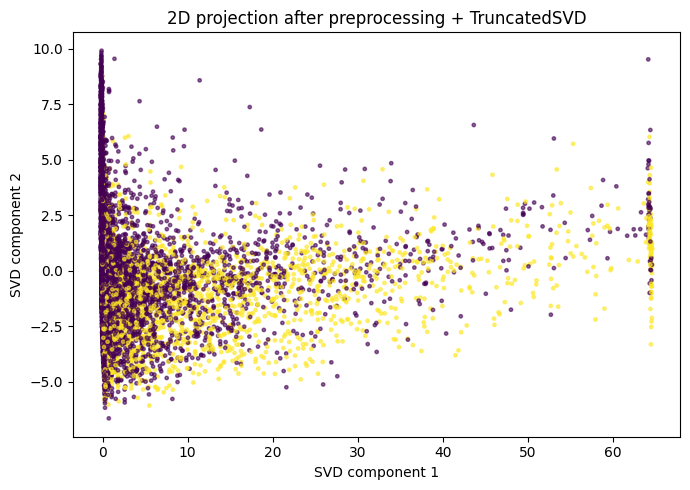

In [23]:
feature_preprocessor = Pipeline(
    steps=[
        ("drop_service", ColumnDropper(LEAKAGE_COLUMNS + [TARGET])),
        ("features", FeatureEngineer(drop_date=True)),
        ("outliers", OutlierClipper()),
        ("preprocess", build_column_preprocessor()),
    ]
)

svd_2d = Pipeline(
    steps=[
        ("feature_preprocessor", feature_preprocessor),
        ("svd", TruncatedSVD(n_components=2, random_state=RANDOM_STATE)),
    ]
)

sample_size = min(15000, len(X_train))
sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_train), size=sample_size, replace=False)

X_train_sample = X_train.iloc[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

X_2d = svd_2d.fit_transform(X_train_sample, y_train_sample)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train_sample, s=6, alpha=0.6)
plt.title("2D projection after preprocessing + TruncatedSVD")
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.tight_layout()
plt.show()

In [24]:
svd_lgbm_pipeline = Pipeline(
    steps=[
        ("drop_service", ColumnDropper(LEAKAGE_COLUMNS + [TARGET])),
        ("features", FeatureEngineer(drop_date=True)),
        ("outliers", OutlierClipper()),
        ("preprocess", build_column_preprocessor()),
        ("svd", TruncatedSVD(n_components=30, random_state=RANDOM_STATE)),
        (
            "model",
            LGBMClassifier(
                **best_lgbm_params,
                objective="binary",
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=1,
                verbose=-1,
            ),
        ),
    ]
)

svd_lgbm_pipeline.fit(X_train, y_train)

svd_lgbm_score = predict_proba_positive(svd_lgbm_pipeline, X_val)
svd_lgbm_threshold, _ = find_best_threshold(y_val, svd_lgbm_score)

svd_lgbm_val_metrics = evaluate_binary_classifier(
    svd_lgbm_pipeline,
    X_val,
    y_val,
    svd_lgbm_threshold,
)

svd_lgbm_test_metrics = evaluate_binary_classifier(
    svd_lgbm_pipeline,
    X_test,
    y_test,
    svd_lgbm_threshold,
)

svd_lgbm_name = f"Tuned LightGBM + FE + SVD30 {best_lgbm_params}"

svd_rows = pd.DataFrame([
    metrics_to_row(svd_lgbm_name, "val", svd_lgbm_val_metrics, svd_lgbm_threshold),
    metrics_to_row(svd_lgbm_name, "test", svd_lgbm_test_metrics, svd_lgbm_threshold),
])

results_df = pd.concat([results_df, svd_rows], ignore_index=True)
fitted_models[svd_lgbm_name] = svd_lgbm_pipeline

results_df.sort_values(["split", "pr_auc"], ascending=[True, False])

,model,split,threshold,accuracy,precision,recall,f1,pr_auc,roc_auc
17,"Tuned LightGBM + FE {'colsample_bytree': 0.8, ...",test,0.52,0.819401,0.592961,0.764752,0.667988,0.748909,0.884757
0,LightGBM + FE,test,0.33,0.835529,0.641805,0.696270,0.667929,0.740999,0.880035
1,XGBoost + FE,test,0.30,0.823574,0.610434,0.711269,0.657005,0.726754,0.871910
19,Fast SoftVoting ensemble + LightGBM,test,0.56,0.818932,0.597382,0.729426,0.656833,0.723577,0.872794
2,ExtraTrees + FE,test,0.39,0.815369,0.589052,0.736925,0.654743,0.719727,0.872427
3,RandomForest + FE,test,0.46,0.824746,0.615465,0.699033,0.654592,0.716132,0.870854
23,Tuned LightGBM + FE + SVD30 {'colsample_bytree...,test,0.54,0.817385,0.598092,0.705151,0.647224,0.710379,0.867833
4,GradientBoosting + FE,test,0.27,0.815556,0.594971,0.700414,0.643401,0.709638,0.861822
5,LogisticRegression + FE,test,0.58,0.814712,0.593839,0.696270,0.640988,0.694923,0.860116
6,Baseline LogisticRegression,test,0.58,0.815463,0.597652,0.683047,0.637502,0.693955,0.857517


## 14. Таблица экспериментов

Сортируем validation-результаты по главной метрике `PR-AUC`


In [25]:
results_df = results_df.sort_values(["split", "pr_auc"], ascending=[True, False]).reset_index(drop=True)

val_leaderboard = (
    results_df[results_df["split"] == "val"]
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

test_table = (
    results_df[results_df["split"] == "test"]
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

display(val_leaderboard)
display(test_table)

MODELS_DIR.mkdir(exist_ok=True, parents=True)
results_df.to_csv(MODELS_DIR / "experiment_results.csv", index=False)
print("Saved:", MODELS_DIR / "experiment_results.csv")

,model,split,threshold,accuracy,precision,recall,f1,pr_auc,roc_auc
0,"Tuned LightGBM + FE {'colsample_bytree': 0.8, ...",val,0.52,0.843687,0.598261,0.711561,0.650010,0.722990,0.891111
1,LightGBM + FE,val,0.33,0.854095,0.641406,0.645829,0.643610,0.712421,0.886261
2,XGBoost + FE,val,0.30,0.845375,0.611429,0.663985,0.636624,0.704638,0.881682
3,Fast SoftVoting ensemble + LightGBM,val,0.56,0.839280,0.592615,0.678695,0.632741,0.703897,0.881948
4,ExtraTrees + FE,val,0.39,0.835764,0.582458,0.688348,0.630991,0.697227,0.881351
5,RandomForest + FE,val,0.46,0.843171,0.609491,0.643530,0.626048,0.692926,0.878399
6,Tuned LightGBM + FE + SVD30 {'colsample_bytree...,val,0.54,0.837826,0.590983,0.665824,0.626175,0.691100,0.876609
7,GradientBoosting + FE,val,0.27,0.835482,0.585465,0.662836,0.621753,0.688825,0.872504
8,LogisticRegression + FE,val,0.58,0.836795,0.589950,0.655711,0.621095,0.678786,0.870569
9,Baseline LogisticRegression,val,0.58,0.834591,0.585250,0.649276,0.615603,0.673437,0.867547


,model,split,threshold,accuracy,precision,recall,f1,pr_auc,roc_auc
0,"Tuned LightGBM + FE {'colsample_bytree': 0.8, ...",test,0.52,0.819401,0.592961,0.764752,0.667988,0.748909,0.884757
1,LightGBM + FE,test,0.33,0.835529,0.641805,0.696270,0.667929,0.740999,0.880035
2,XGBoost + FE,test,0.30,0.823574,0.610434,0.711269,0.657005,0.726754,0.871910
3,Fast SoftVoting ensemble + LightGBM,test,0.56,0.818932,0.597382,0.729426,0.656833,0.723577,0.872794
4,ExtraTrees + FE,test,0.39,0.815369,0.589052,0.736925,0.654743,0.719727,0.872427
5,RandomForest + FE,test,0.46,0.824746,0.615465,0.699033,0.654592,0.716132,0.870854
6,Tuned LightGBM + FE + SVD30 {'colsample_bytree...,test,0.54,0.817385,0.598092,0.705151,0.647224,0.710379,0.867833
7,GradientBoosting + FE,test,0.27,0.815556,0.594971,0.700414,0.643401,0.709638,0.861822
8,LogisticRegression + FE,test,0.58,0.814712,0.593839,0.696270,0.640988,0.694923,0.860116
9,Baseline LogisticRegression,test,0.58,0.815463,0.597652,0.683047,0.637502,0.693955,0.857517


Saved: /home/kali/Desktop/weather-rain-repo/models/experiment_results.csv


## 15. Выбор финальной модели

Финальная модель - модель с максимальным `PR-AUC` на validation.  
Threshold выбран по validation по максимуму F1. Test-метрики смотрим только после выбора.


In [26]:
best_model_name = val_leaderboard.loc[0, "model"]
best_threshold = float(val_leaderboard.loc[0, "threshold"])
best_model = fitted_models[best_model_name]

print("Best model:", best_model_name)
print("Best validation PR-AUC:", val_leaderboard.loc[0, "pr_auc"])
print("Selected threshold:", best_threshold)

final_test_metrics = evaluate_binary_classifier(best_model, X_test, y_test, threshold=best_threshold)
final_test_metrics

Best model: Tuned LightGBM + FE {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_samples': 40, 'n_estimators': 500, 'num_leaves': 63, 'reg_lambda': 1.0, 'subsample': 0.8}
Best validation PR-AUC: 0.7229898724389779
Selected threshold: 0.5199999999999999


{'accuracy': 0.8194008157907074,
 'precision': np.float64(0.5929609793420046),
 'recall': np.float64(0.7647523189263864),
 'f1': np.float64(0.6679882778831236),
 'pr_auc': np.float64(0.748909167087357),
 'confusion_matrix': [[13602, 2660], [1192, 3875]],
 'roc_auc': np.float64(0.8847566153088644)}

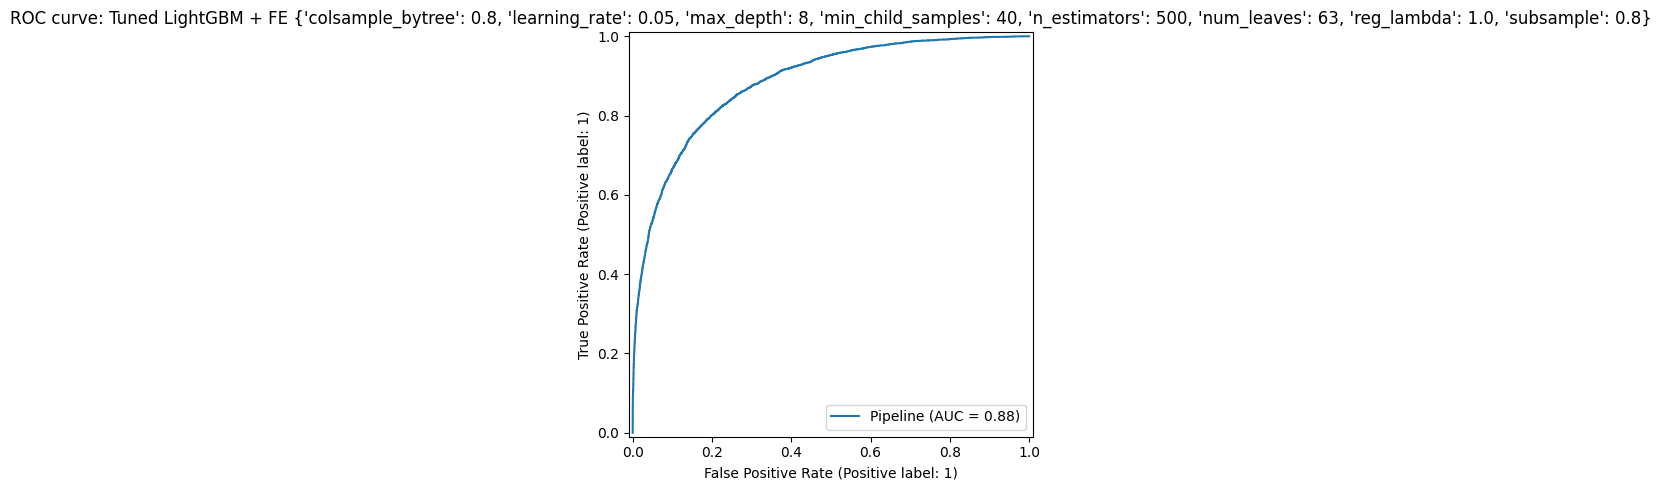

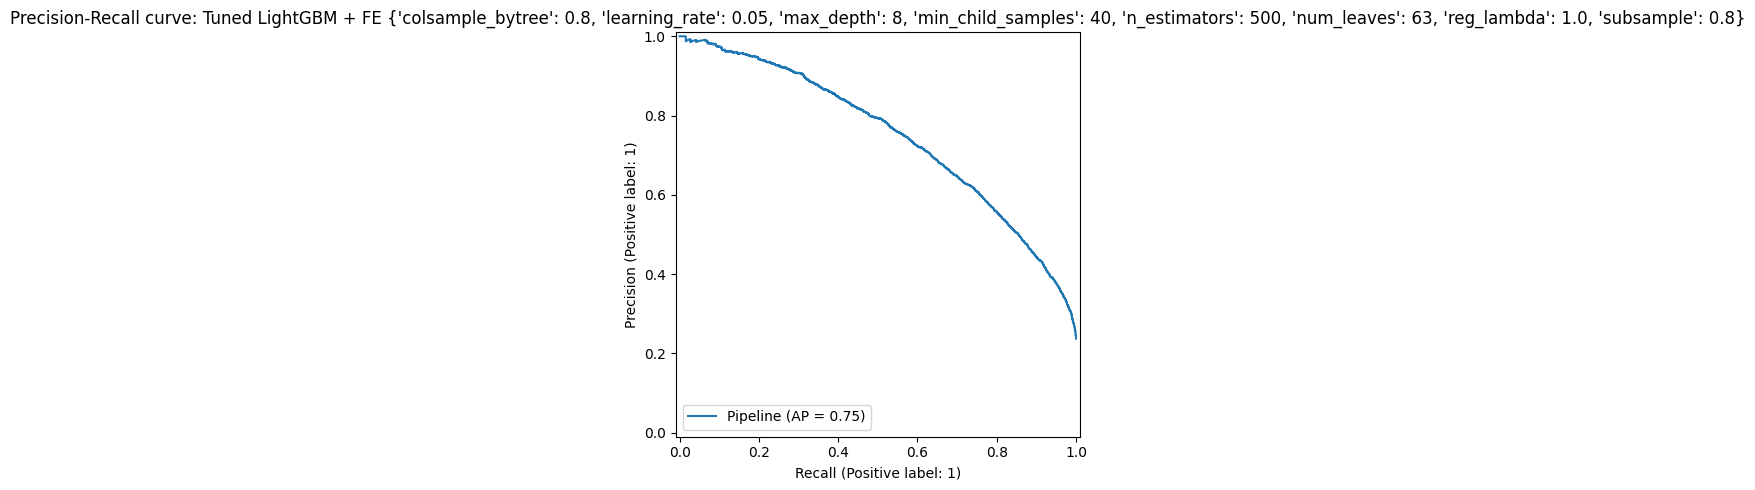

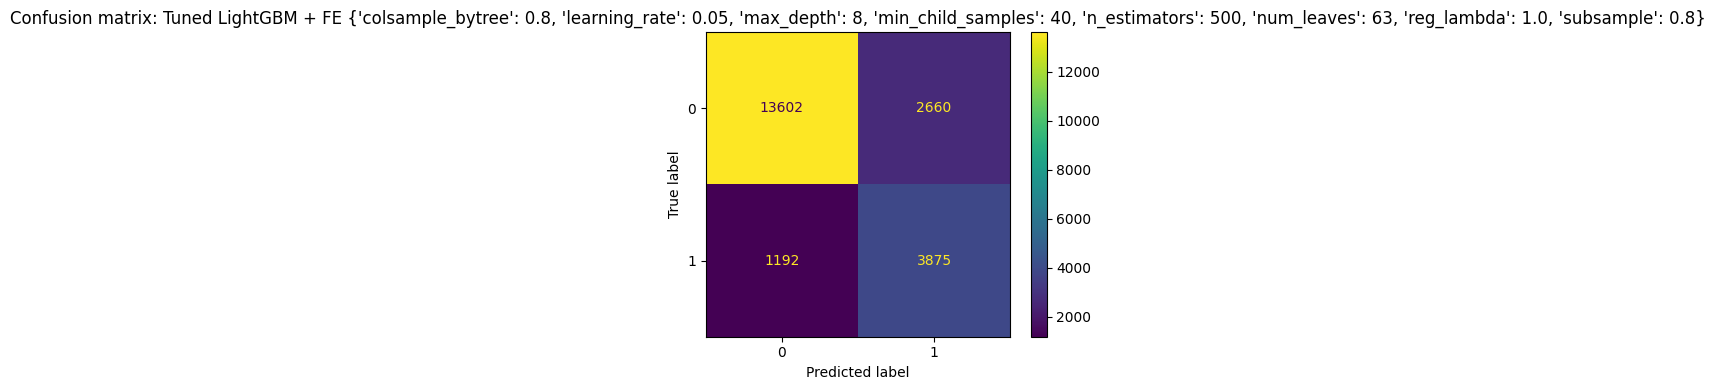

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax)
plt.title(f"ROC curve: {best_model_name}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax)
plt.title(f"Precision-Recall curve: {best_model_name}")
plt.tight_layout()
plt.show()

y_test_score = predict_proba_positive(best_model, X_test)
y_test_pred = (y_test_score >= best_threshold).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax)
plt.title(f"Confusion matrix: {best_model_name}")
plt.tight_layout()
plt.show()

## 16. Важность признаков

Для интерпретируемости смотрим feature importance у RandomForest

Хоть lgbm и лучшая RandomForest importance помогает понять, какие признаки сильнее всего связаны с прогнозом


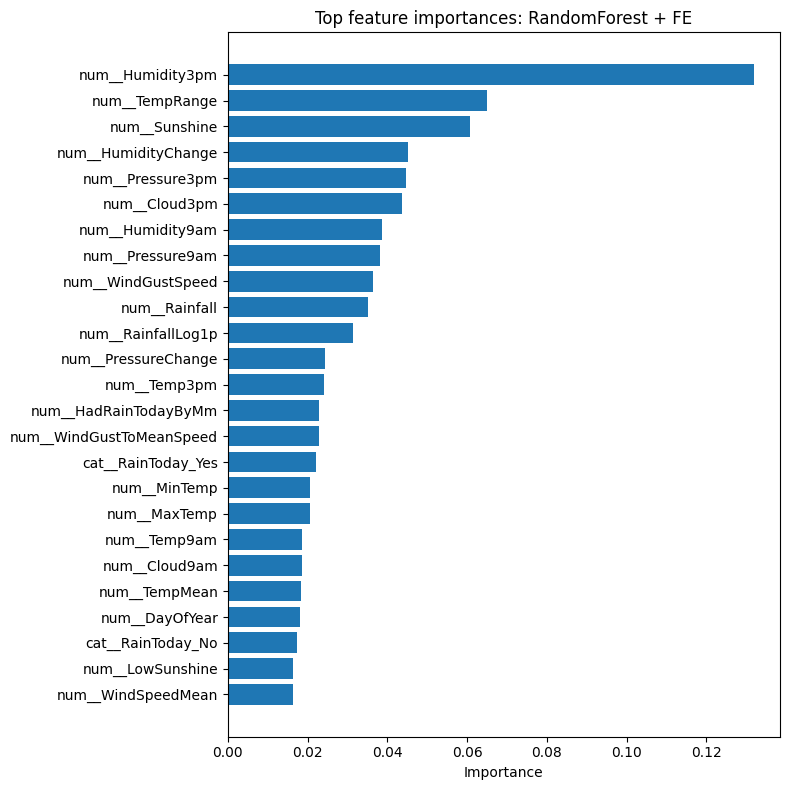

,feature,importance
9,num__Humidity3pm,0.131883
20,num__TempRange,0.064978
4,num__Sunshine,0.060658
22,num__HumidityChange,0.045157
11,num__Pressure3pm,0.044578
13,num__Cloud3pm,0.043802
8,num__Humidity9am,0.038760
10,num__Pressure9am,0.038086
5,num__WindGustSpeed,0.036321
2,num__Rainfall,0.035086


In [28]:
rf_for_importance_name = "RandomForest + FE"
if rf_for_importance_name not in fitted_models:
    rf_for_importance_name = tuned_rf_name

rf_pipe = fitted_models[rf_for_importance_name]

try:
    feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()
    importances = rf_pipe.named_steps["model"].feature_importances_

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(25)
    )

    plt.figure(figsize=(8, 8))
    plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
    plt.title(f"Top feature importances: {rf_for_importance_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    display(importance_df)
except Exception as exc:
    print("Feature importance is unavailable for this model:", exc)

## 17. Сохранение модели

Сохраняем финальную модель и таблицу экспериментов


In [30]:
model_path = MODELS_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)

results_df.to_csv(MODELS_DIR / "experiment_results.csv", index=False)